# NB2 — Autoencoder Training (Lab Data)

**Differences from N-CMAPSS:**
- Smaller AE: `base_ch=16, latent_dim=32` (half size — fewer nominal windows)
- `n_sensors=29, window_size=100` (10 Hz lab data)
- Higher dropout (0.2) to prevent overfitting on limited data
- Same training loop, same outputs


In [1]:
import sys, os, pickle, warnings, logging, json
warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(asctime)s [%(levelname)s] %(message)s')

import numpy as np
import matplotlib.pyplot as plt
import torch

sys.path.insert(0, '..')
from models import ConvAutoencoder, AETrainer, DEVICE

PROC_DIR = '../processed_data'
CKPT_DIR = '../checkpoints'
PLOT_DIR = '../plots'

print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')

2026-04-22 13:17:44,389 [INFO] GPU: NVIDIA RTX 4500 Ada Generation


Device : cuda
GPU    : NVIDIA RTX 4500 Ada Generation


In [2]:
X_nominal = np.load(f'{PROC_DIR}/X_nominal.npy')
with open(f'{PROC_DIR}/sensor_cols.pkl', 'rb') as f:
    sensor_cols = pickle.load(f)
with open(f'{CKPT_DIR}/lab_meta.json') as f:
    meta = json.load(f)

WINDOW_SIZE = X_nominal.shape[1]   # 100
N_SENSORS   = X_nominal.shape[2]   # 29

# ── AE hyperparameters (smaller than N-CMAPSS due to fewer nominal windows) ──
AE_BASE_CH  = 16     # N-CMAPSS used 32
AE_LATENT   = 32     # N-CMAPSS used 64
AE_DROPOUT  = 0.20   # slightly higher for regularisation
AE_EPOCHS   = 150    # more epochs to compensate for smaller dataset
BATCH_SIZE  = 128    # smaller batch (fewer windows)
LR          = 1e-3
PATIENCE    = 20

print(f'X_nominal shape  : {X_nominal.shape}')
print(f'Window size      : {WINDOW_SIZE} samples ({WINDOW_SIZE/10:.0f}s at 10Hz)')
print(f'N sensors        : {N_SENSORS}')
print(f'AE base_ch={AE_BASE_CH}, latent_dim={AE_LATENT}, epochs={AE_EPOCHS}')

X_nominal shape  : (16022, 100, 29)
Window size      : 100 samples (10s at 10Hz)
N sensors        : 29
AE base_ch=16, latent_dim=32, epochs=150


In [3]:
ae_model = ConvAutoencoder(
    n_sensors   = N_SENSORS,
    window_size = WINDOW_SIZE,
    base_ch     = AE_BASE_CH,
    latent_dim  = AE_LATENT,
    dropout_p   = AE_DROPOUT,
)
n_params = sum(p.numel() for p in ae_model.parameters())
print(f'AE parameters: {n_params:,}')

ae_trainer = AETrainer(ae_model, lr=LR, device=DEVICE)
print(f'Training on {len(X_nominal):,} nominal windows …')

val_losses = ae_trainer.fit(
    X_nominal,
    epochs     = AE_EPOCHS,
    batch_size = BATCH_SIZE,
    val_split  = 0.1,
    patience   = PATIENCE,
)

torch.save(ae_model.state_dict(), f'{CKPT_DIR}/autoencoder.pt')
print(f'\n✓ Autoencoder saved → {CKPT_DIR}/autoencoder.pt')

2026-04-22 13:17:53,953 [INFO] AE Bottleneck: 1664 -> 32 -> 1664


AE parameters: 176,573
Training on 16,022 nominal windows …


2026-04-22 13:18:09,451 [INFO] AE Epoch  10/150 | train=0.003950 | val=0.003713
2026-04-22 13:18:22,989 [INFO] AE Epoch  20/150 | train=0.002113 | val=0.002944
2026-04-22 13:18:36,456 [INFO] AE Epoch  30/150 | train=0.001596 | val=0.003153
2026-04-22 13:18:47,275 [INFO] Early stop at epoch 38



✓ Autoencoder saved → ../checkpoints/autoencoder.pt


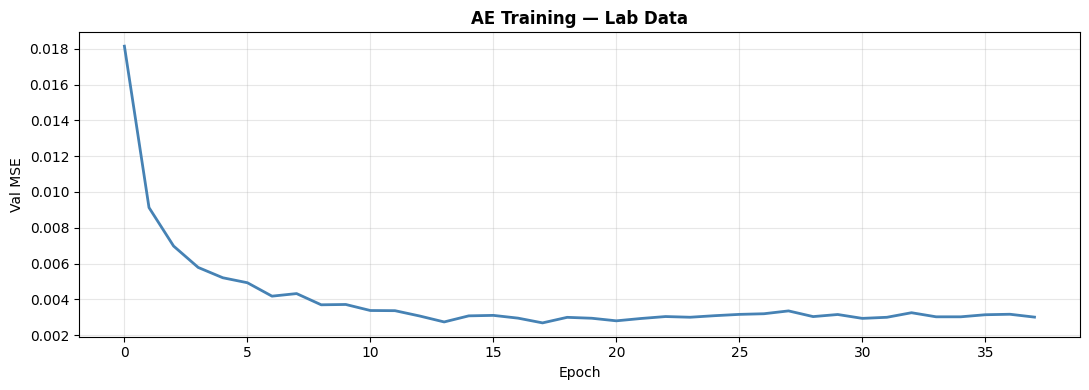

Best validation MSE : 0.002684


In [4]:
# Training curve
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(val_losses, lw=2, color='steelblue')
ax.set_xlabel('Epoch'); ax.set_ylabel('Val MSE')
ax.set_title('AE Training — Lab Data', fontweight='bold')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/nb2_ae_training_curve.png', dpi=120)
plt.show()
print(f'Best validation MSE : {min(val_losses):.6f}')

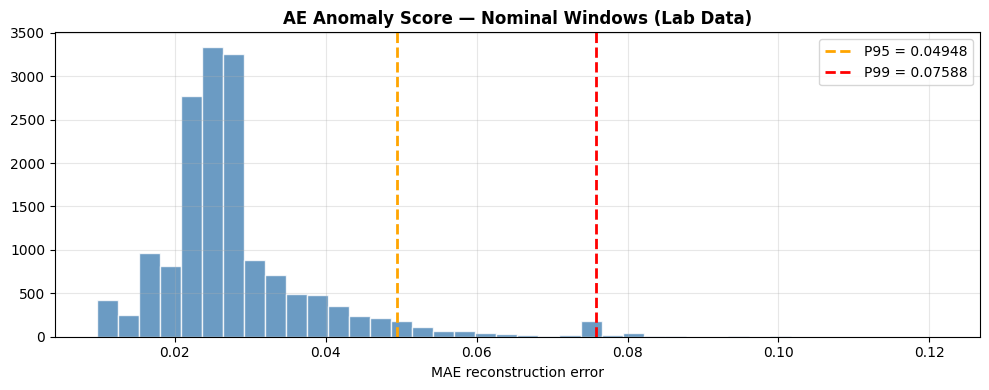

Nominal MAE mean : 0.028222
P95 threshold    : 0.049481  (5% FPR)
P99 threshold    : 0.075877  (1% FPR)
Saved ae_thresholds.json


In [5]:
# Anomaly score distribution on nominal data
RECON_BATCH = 256
re_scores = []
for i in range(0, len(X_nominal), RECON_BATCH):
    chunk = X_nominal[i:i+RECON_BATCH]
    recon = ae_trainer.reconstruct(chunk)
    re_scores.append(np.abs(chunk - recon).mean(axis=(1, 2)))
re_scores = np.concatenate(re_scores)

RE_THRESH_95 = float(np.percentile(re_scores, 95))
RE_THRESH_99 = float(np.percentile(re_scores, 99))

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(re_scores, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(RE_THRESH_95, color='orange', ls='--', lw=2, label=f'P95 = {RE_THRESH_95:.5f}')
ax.axvline(RE_THRESH_99, color='red',    ls='--', lw=2, label=f'P99 = {RE_THRESH_99:.5f}')
ax.set_xlabel('MAE reconstruction error')
ax.set_title('AE Anomaly Score — Nominal Windows (Lab Data)', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/nb2_anomaly_score_dist.png', dpi=120)
plt.show()

print(f'Nominal MAE mean : {re_scores.mean():.6f}')
print(f'P95 threshold    : {RE_THRESH_95:.6f}  (5% FPR)')
print(f'P99 threshold    : {RE_THRESH_99:.6f}  (1% FPR)')

import json
with open(f'{CKPT_DIR}/ae_thresholds.json', 'w') as f:
    json.dump({'RE_THRESH_95': RE_THRESH_95, 'RE_THRESH_99': RE_THRESH_99,
               'ae_nominal_mae': float(re_scores.mean())}, f, indent=2)
print(f'Saved ae_thresholds.json')

In [6]:
# Save reconstructions of all nominal windows
print('Reconstructing all nominal windows …')
X_recon_nominal = np.zeros_like(X_nominal)
for i in range(0, len(X_nominal), RECON_BATCH):
    X_recon_nominal[i:i+RECON_BATCH] = ae_trainer.reconstruct(X_nominal[i:i+RECON_BATCH])

np.save(f'{PROC_DIR}/X_recon_nominal.npy', X_recon_nominal)
print(f'Saved X_recon_nominal → {PROC_DIR}/')
print('\n✓ NB2 complete — Proceed to NB3_Clustering_ANN.ipynb')

Reconstructing all nominal windows …
Saved X_recon_nominal → ../processed_data/

✓ NB2 complete — Proceed to NB3_Clustering_ANN.ipynb


---
## ↻ Reload Block

In [7]:
import sys, os, pickle, json, warnings
import numpy as np, torch
warnings.filterwarnings('ignore')
sys.path.insert(0, '..')
from models import ConvAutoencoder, AETrainer, DEVICE

PROC_DIR = '../processed_data'; CKPT_DIR = '../checkpoints'
with open(f'{PROC_DIR}/sensor_cols.pkl', 'rb') as f: sensor_cols = pickle.load(f)
with open(f'{CKPT_DIR}/lab_meta.json')          as f: meta = json.load(f)

X_nominal = np.load(f'{PROC_DIR}/X_nominal.npy')
ae_model  = ConvAutoencoder(
    n_sensors=X_nominal.shape[2], window_size=X_nominal.shape[1],
    base_ch=16, latent_dim=32, dropout_p=0.20
).to(DEVICE)
ae_model.load_state_dict(torch.load(f'{CKPT_DIR}/autoencoder.pt',
                                     map_location=DEVICE, weights_only=True))
ae_model.eval()
ae_trainer = AETrainer(ae_model, device=DEVICE)
print(f'✓ AE reloaded. X_nominal={X_nominal.shape}')

2026-04-16 15:11:41,921 [INFO] AE Bottleneck: 1664 -> 32 -> 1664


✓ AE reloaded. X_nominal=(16499, 100, 29)
